In [56]:
# Import Libraries and Load Amazon Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Amazon Sale Report.csv')
print(f" shape : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n Original Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. '{col}'")
print(f"\n First 3 rows of raw data:")
print(df.head(3))


 shape : 128975 rows, 24 columns

 Original Column Names:
   1. 'index'
   2. 'Order ID'
   3. 'Date'
   4. 'Status'
   5. 'Fulfilment'
   6. 'Sales Channel '
   7. 'ship-service-level'
   8. 'Style'
   9. 'SKU'
   10. 'Category'
   11. 'Size'
   12. 'ASIN'
   13. 'Courier Status'
   14. 'Qty'
   15. 'currency'
   16. 'Amount'
   17. 'ship-city'
   18. 'ship-state'
   19. 'ship-postal-code'
   20. 'ship-country'
   21. 'promotion-ids'
   22. 'B2B'
   23. 'fulfilled-by'
   24. 'Unnamed: 22'

 First 3 rows of raw data:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in     

 Column Mapping and Feature Engineering
 Found Price column: 'Amount'
   Price range: 0.00 to 5584.00
 No Rating column found.
   Rating range: 1.80 to 5.00
 Found Category column: 'Category'
 Found Product ID column: 'ASIN'
 No User ID column found User IDs.

 Creating missing behavioral columns
 Created 'Purchase Status'
 Created synthetic 'Number of Views'
 Created 'Time Spent'
  Created 'Cart Status'
 Created 'Previous Purchases'

 Final Dataset ready 
   Columns: ['User ID', 'Product ID', 'Product Category', 'Rating', 'Price', 'Purchase Status', 'Number of Views', 'Cart Status', 'Time Spent', 'Previous Purchases']

 First 5 rows:
  User ID  Product ID Product Category  Rating   Price  Purchase Status  \
0  U00001  B09KXVBD7Z              Set     5.0  647.62                1   
1  U00002  B09K3WFS32            Kurta     4.9  406.00                1   
2  U00003  B07WV4JV4D            Kurta     4.4  329.00                1   
3  U00004  B099NRCT7B    Western Dress     5.0  753.33   

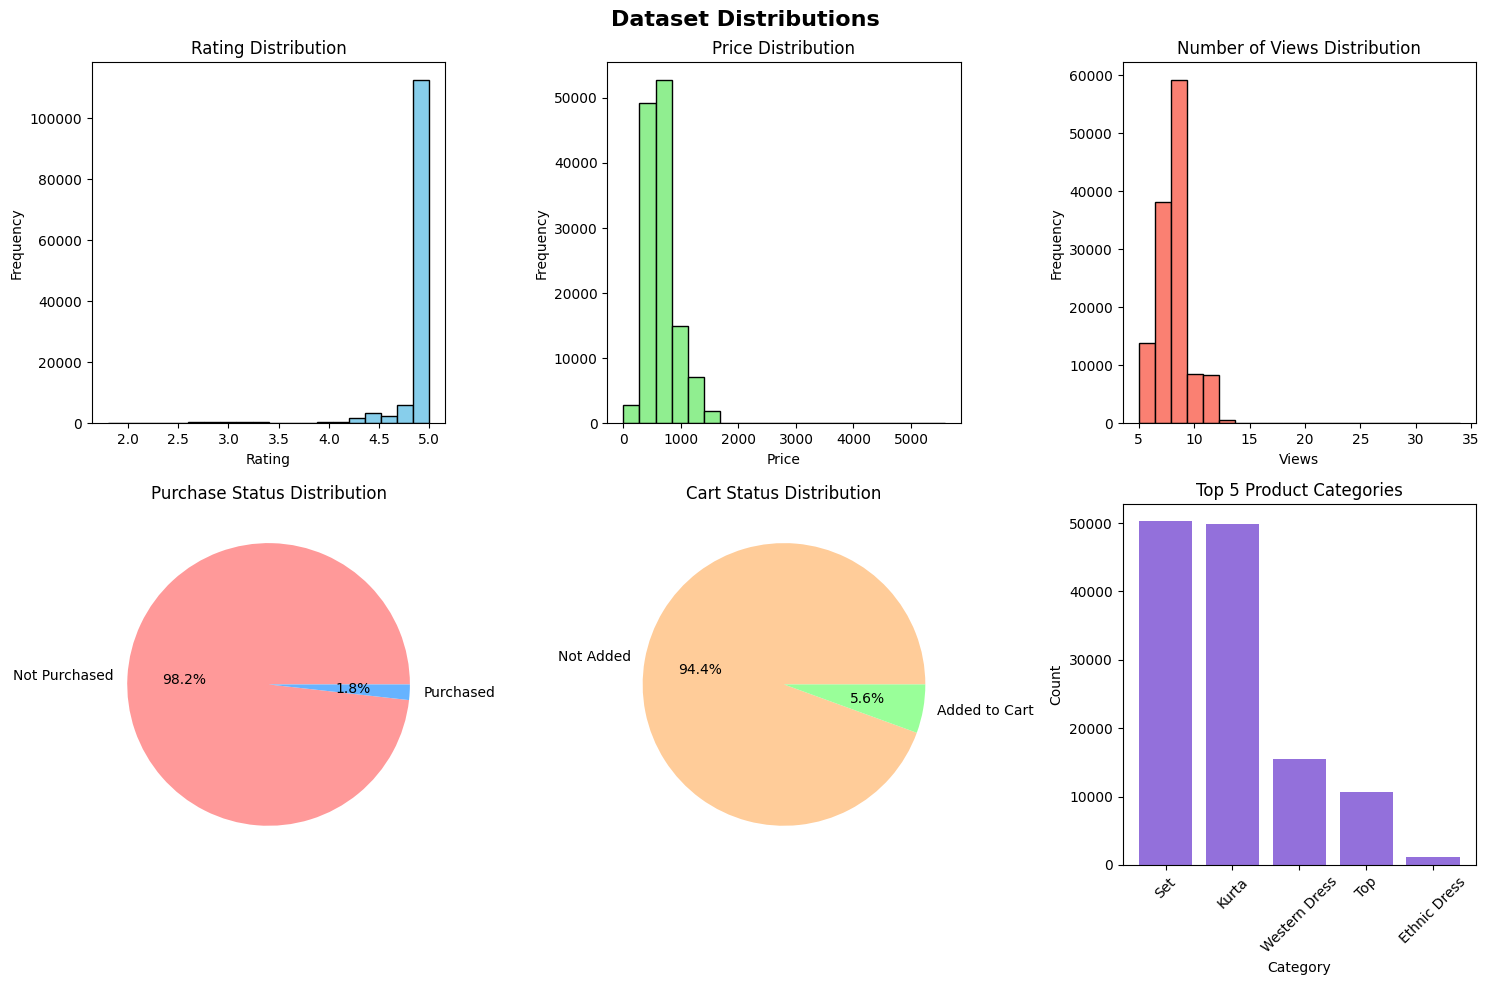

In [57]:
# Smart Column Mapping and Feature Engineering

print(" Column Mapping and Feature Engineering")

#  Find and Clean Price Column
price_col = None
for col in df.columns:
    if 'price' in col.lower() or 'amount' in col.lower() or 'cost' in col.lower():
        price_col = col
        break

if price_col:
    print(f" Found Price column: '{price_col}'")
    df[price_col] = df[price_col].astype(str).str.replace(r'[\$,]', '', regex=True)
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df.rename(columns={price_col: 'Price'}, inplace=True)
else:
    print(" No Price column found ")
    df['Price'] = np.random.randint(50, 500, len(df))

df['Price'] = df['Price'].fillna(df['Price'].median())
print(f"   Price range: {df['Price'].min():.2f} to {df['Price'].max():.2f}")

# Find and Clean Rating Column
rating_col = None
for col in df.columns:
    if 'rating' in col.lower() or 'star' in col.lower() or 'score' in col.lower():
        rating_col = col
        break

if rating_col:
    print(f" Found Rating column: '{rating_col}'")
    df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')
    df.rename(columns={rating_col: 'Rating'}, inplace=True)
else:
    print(" No Rating column found.")
    df['Rating'] = np.clip((df['Price'] / 200) + np.random.normal(3, 0.3, len(df)), 1, 5).round(1)

df['Rating'] = df['Rating'].fillna(df['Rating'].median())
print(f"   Rating range: {df['Rating'].min():.2f} to {df['Rating'].max():.2f}")

# Find and Map Category Column
cat_col = None
for col in df.columns:
    if 'category' in col.lower() or 'sub_category' in col.lower():
        cat_col = col
        break

if cat_col:
    print(f" Found Category column: '{cat_col}'")
    #  remove extra spaces, capitalize
    df[cat_col] = df[cat_col].astype(str).str.strip().str.title()
    df.rename(columns={cat_col: 'Product Category'}, inplace=True)
else:
    print(" No Category column found. Using default.")
    df['Product Category'] = 'Electronics'

# Find and Map Product ID
prod_col = None
for col in df.columns:
    if 'product_id' in col.lower() or 'asin' in col.lower():
        prod_col = col
        break

if prod_col:
    print(f" Found Product ID column: '{prod_col}'")
    df.rename(columns={prod_col: 'Product ID'}, inplace=True)
else:
    print(" No Product ID column found.")
    df['Product ID'] = [f'P{i:05d}' for i in range(1, len(df)+1)]

# 5. Create User ID if missing
if 'User ID' not in df.columns:
    print(" No User ID column found User IDs.")
    df['User ID'] = [f'U{i:05d}' for i in range(1, len(df)+1)]
else:
    print(f" Found User ID column: 'User ID'")
    df['User ID'] = df['User ID'].astype(str)

# Create Missing Behavioral Columns
print("\n Creating missing behavioral columns")

if 'Purchase Status' not in df.columns:
    df['Purchase Status'] = (df['Rating'] > 3.5).astype(int)
    print(" Created 'Purchase Status'")

if 'Number of Views' not in df.columns:
    if 'rating_count' in df.columns:
        df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(df['rating_count'].median())
        df['Number of Views'] = (df['rating_count'] / 5).astype(int).clip(1, 50)
        print(" Created Number of Views:")
    else:
        price_norm = (df['Price'] - df['Price'].min()) / (df['Price'].max() - df['Price'].min() + 1)
        df['Number of Views'] = (price_norm * 30 + 5).fillna(0).astype(int).clip(1, 50)
        print(" Created synthetic 'Number of Views'")

if 'Time Spent' not in df.columns:
    price_norm = (df['Price'] - df['Price'].min()) / (df['Price'].max() - df['Price'].min() + 1)
    df['Time Spent'] = (price_norm * 150 + 30).fillna(0).astype(int).clip(10, 300)
    print(" Created 'Time Spent'")

if 'Cart Status' not in df.columns:
    cart_prob = 1 / (1 + np.exp(-((df['Rating'] - 2.5) * 0.8 + df['Price'] / 200 - 1.5)))
    df['Cart Status'] = np.random.binomial(1, cart_prob)
    print("  Created 'Cart Status'")

if 'Previous Purchases' not in df.columns:
    df['Previous Purchases'] = np.random.randint(1, 15, len(df))
    print(" Created 'Previous Purchases'")

# Keep only required columns
required_cols = ['User ID', 'Product ID', 'Product Category', 'Rating', 'Price',
                 'Purchase Status', 'Number of Views', 'Cart Status', 'Time Spent', 'Previous Purchases']
df = df[[c for c in required_cols if c in df.columns]]

print(f"\n Final Dataset ready ")
print(f"   Columns: {df.columns.tolist()}")
print(f"\n First 5 rows:")
print(df.head())
print(f"\n Missing values check: {df.isnull().sum().sum()} missing values found.")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Dataset Distributions', fontsize=16, fontweight='bold')

# Rating distribution
axes[0, 0].hist(df['Rating'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')

# Price distribution
axes[0, 1].hist(df['Price'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Price Distribution')
axes[0, 1].set_xlabel('Price')
axes[0, 1].set_ylabel('Frequency')

# Views distribution
axes[0, 2].hist(df['Number of Views'], bins=20, color='salmon', edgecolor='black')
axes[0, 2].set_title('Number of Views Distribution')
axes[0, 2].set_xlabel('Views')
axes[0, 2].set_ylabel('Frequency')

# Purchase Status pie chart
purchase_counts = df['Purchase Status'].value_counts()
axes[1, 0].pie(purchase_counts.values, labels=['Not Purchased', 'Purchased'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1, 0].set_title('Purchase Status Distribution')

# Cart Status pie chart
cart_counts = df['Cart Status'].value_counts()
axes[1, 1].pie(cart_counts.values, labels=['Not Added', 'Added to Cart'], autopct='%1.1f%%', colors=['#ffcc99','#99ff99'])
axes[1, 1].set_title('Cart Status Distribution')

# Category distribution
category_counts = df['Product Category'].value_counts().head(5)
axes[1, 2].bar(category_counts.index, category_counts.values, color='mediumpurple')
axes[1, 2].set_title('Top 5 Product Categories')
axes[1, 2].set_xlabel('Category')
axes[1, 2].set_ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()





 Data Preprocessing
Duplicates removed (128975, 10)
 Total features: 17
 Features shape: (128975, 13)
 Regression target (Rating): (128975,)
 Classification target (Purchase Status): (128975,)
 Features scaled: ['Price', 'Number of Views', 'Time Spent', 'Previous Purchases']

 Feature statistics after scaling:
           Price  Number of Views  Time Spent  Previous Purchases
count  128975.00        128975.00   128975.00           128975.00
mean       -0.00             0.00        0.00                0.00
std         1.00             1.00        1.00                1.00
min        -2.37            -2.05       -2.32               -1.62
25%        -0.69            -0.68       -0.67               -0.87
50%        -0.15            -0.00       -0.12                0.12
75%         0.46             0.68        0.43                0.87
max        18.10            17.74       18.15                1.61
 Regression features: 11 (dropped Price & Views)


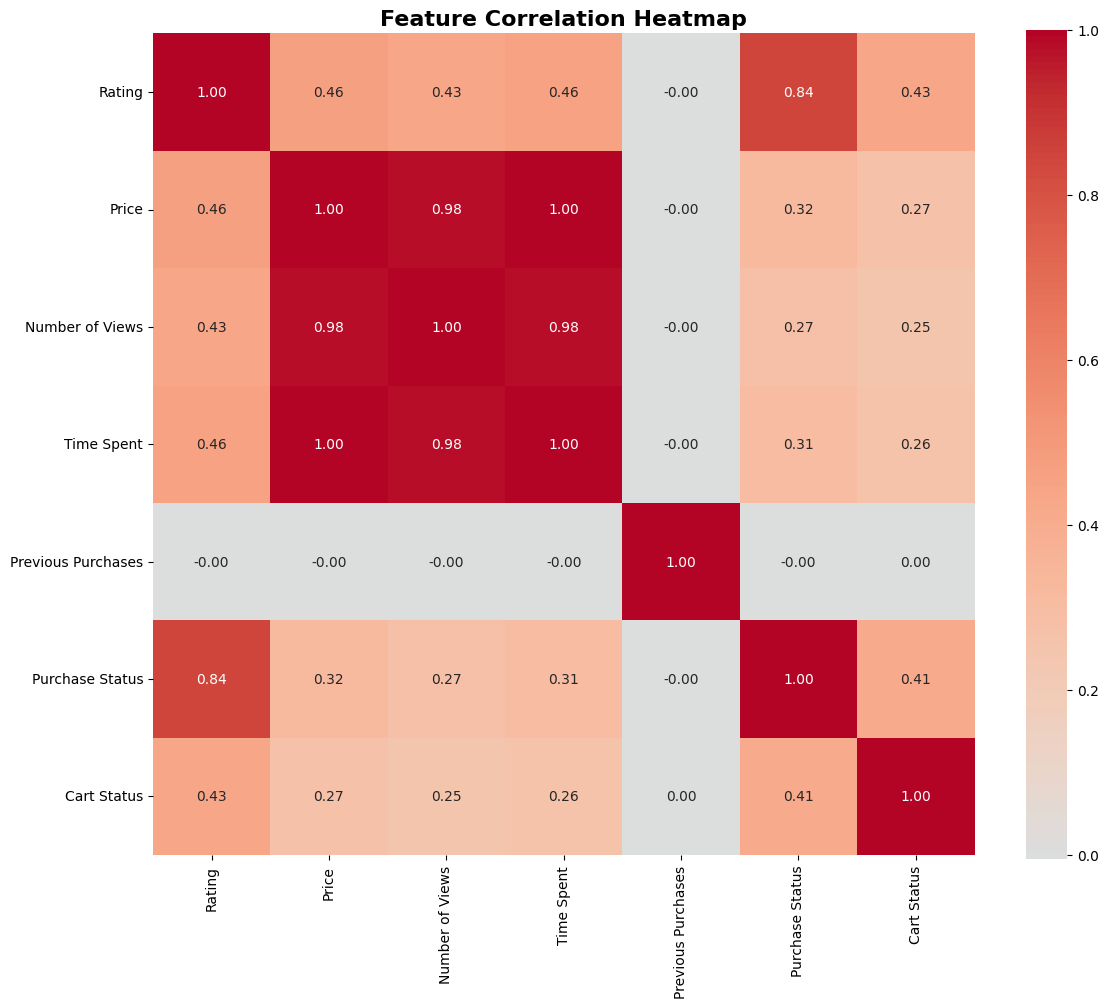

In [58]:
# Data Preprocessing - Encode and Scale

print(" Data Preprocessing")

df.drop_duplicates(inplace=True)
print(f"Duplicates removed {df.shape}")

df_encoded = pd.get_dummies(df, columns=['Product Category'], drop_first=True)
print(f" Total features: {df_encoded.shape[1]}")

# Prepare features and targets
X = df_encoded.drop(['User ID', 'Product ID', 'Rating', 'Purchase Status'], axis=1)
y_reg = df_encoded['Rating']
y_clf = df_encoded['Purchase Status']

print(f" Features shape: {X.shape}")
print(f" Regression target (Rating): {y_reg.shape}")
print(f" Classification target (Purchase Status): {y_clf.shape}")

# Scale numerical features
scaler = StandardScaler()
num_cols = ['Price', 'Number of Views', 'Time Spent', 'Previous Purchases']
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

print(f" Features scaled: {num_cols}")
print(f"\n Feature statistics after scaling:")
print(pd.DataFrame(X_scaled[num_cols]).describe().round(2))


X_reg_scaled = X_scaled.drop(['Price', 'Number of Views'], axis=1)
print(f" Regression features: {X_reg_scaled.shape[1]} (dropped Price & Views)")

plt.figure(figsize=(12, 10))
correlation_matrix = df[['Rating', 'Price', 'Number of Views', 'Time Spent', 'Previous Purchases', 'Purchase Status', 'Cart Status']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




In [59]:
# Train-Test Split
print(" Train-Test Split")

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)
X_train_clf, X_test_clf, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42
)

print(f" Regression split:")
print(f" Training: {X_train.shape[0]} samples")
print(f" Testing:  {X_test.shape[0]} samples")
print(f"\n Classification split:")
print(f" Training: {X_train_clf.shape[0]} samples")
print(f" Testing:  {X_test_clf.shape[0]} samples")

print(f"\n Target distribution - Regression Rating:")
print(y_reg.describe().round(2))
print(f"\n Target distribution - Classification Purchase Status:")
print(f" 0 (Not purchased): {sum(y_clf == 0)}")
print(f" 1 (Purchased):     {sum(y_clf == 1)}")

 Train-Test Split
 Regression split:
 Training: 103180 samples
 Testing:  25795 samples

 Classification split:
 Training: 103180 samples
 Testing:  25795 samples

 Target distribution - Regression Rating:
count    128975.00
mean          4.91
std           0.31
min           1.80
25%           5.00
50%           5.00
75%           5.00
max           5.00
Name: Rating, dtype: float64

 Target distribution - Classification Purchase Status:
 0 (Not purchased): 2278
 1 (Purchased):     126697


Ridge Regression - Rating Prediction
 Hyperparameter grid for tuning:
   alpha: [0.01, 0.1, 1, 10, 50, 100]

 Best alpha: 1

 Regression Performance Metrics:
 MAE  (Mean Absolute Error): 0.149
 MSE  (Mean Squared Error):  0.060
 RMSE (Root Mean Sq Error):  0.246
 R²   (R-squared):           0.341


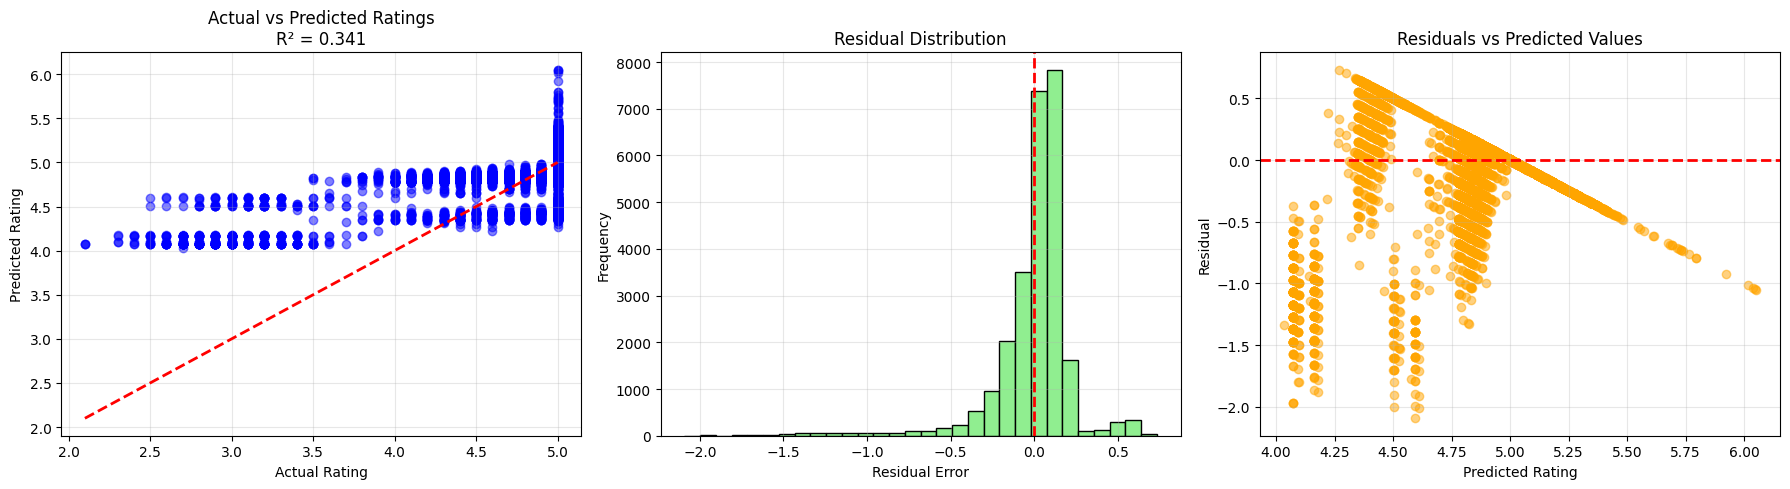

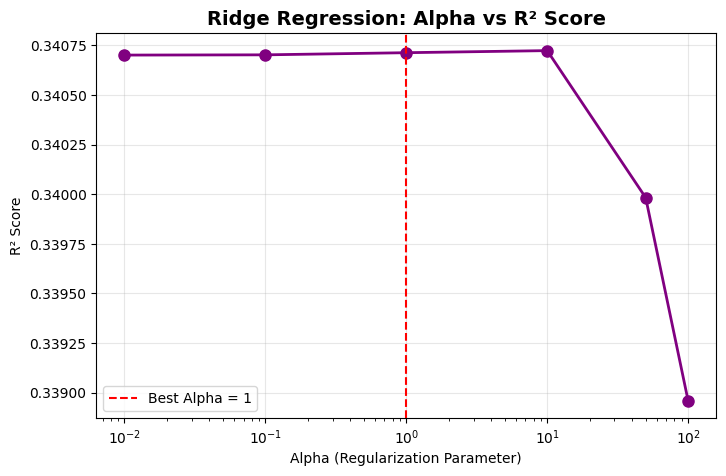

In [60]:
# Ridge Regression - Rating Prediction

try:
    X_train
except NameError:
    raise
print("Ridge Regression - Rating Prediction")

ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}
print(" Hyperparameter grid for tuning:")
print(f"   alpha: {param_grid['alpha']}")

grid = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_reg_train)

best_ridge = grid.best_estimator_
print(f"\n Best alpha: {grid.best_params_['alpha']}")

y_pred_reg = best_ridge.predict(X_test)

mae = mean_absolute_error(y_reg_test, y_pred_reg)
mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_pred_reg)

print(f"\n Regression Performance Metrics:")
print(f" MAE  (Mean Absolute Error): {mae:.3f}")
print(f" MSE  (Mean Squared Error):  {mse:.3f}")
print(f" RMSE (Root Mean Sq Error):  {rmse:.3f}")
print(f" R²   (R-squared):           {r2:.3f}")

# Show sample predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1Actual vs Predicted
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.5, color='blue')
axes[0].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title(f'Actual vs Predicted Ratings\nR² = {r2:.3f}')
axes[0].grid(True, alpha=0.3)

#  2Residuals Distribution
residuals = y_reg_test - y_pred_reg
axes[1].hist(residuals, bins=30, color='lightgreen', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

#  3 Residuals vs Predicted
axes[2].scatter(y_pred_reg, residuals, alpha=0.5, color='orange')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Rating')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted Values')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4 Alpha vs Performance
alpha_values = [0.01, 0.1, 1, 10, 50, 100]
cv_scores = []
for alpha in alpha_values:
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train, y_reg_train)
    y_pred_temp = ridge_temp.predict(X_test)
    cv_scores.append(r2_score(y_reg_test, y_pred_temp))

plt.figure(figsize=(8, 5))
plt.plot(alpha_values, cv_scores, marker='o', linewidth=2, markersize=8, color='purple')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Parameter)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: Alpha vs R² Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=1, color='red', linestyle='--', label='Best Alpha = 1')
plt.legend()
plt.show()

 Logistic Regression - Purchase Prediction
 Hyperparameter grid for tuning:
 C: [0.01, 0.1, 1, 10]
 solver: ['liblinear', 'lbfgs']

 Best parameters: {'C': 0.01, 'solver': 'lbfgs'}

 Classification Performance Metrics:
   Accuracy:  0.999
   Precision: 1.000
   Recall:    0.999
   F1 Score:  1.000

 Confusion Matrix:
                 Predicted
                 No    Yes
   Actual No     444     4
   Actual Yes     17  25330


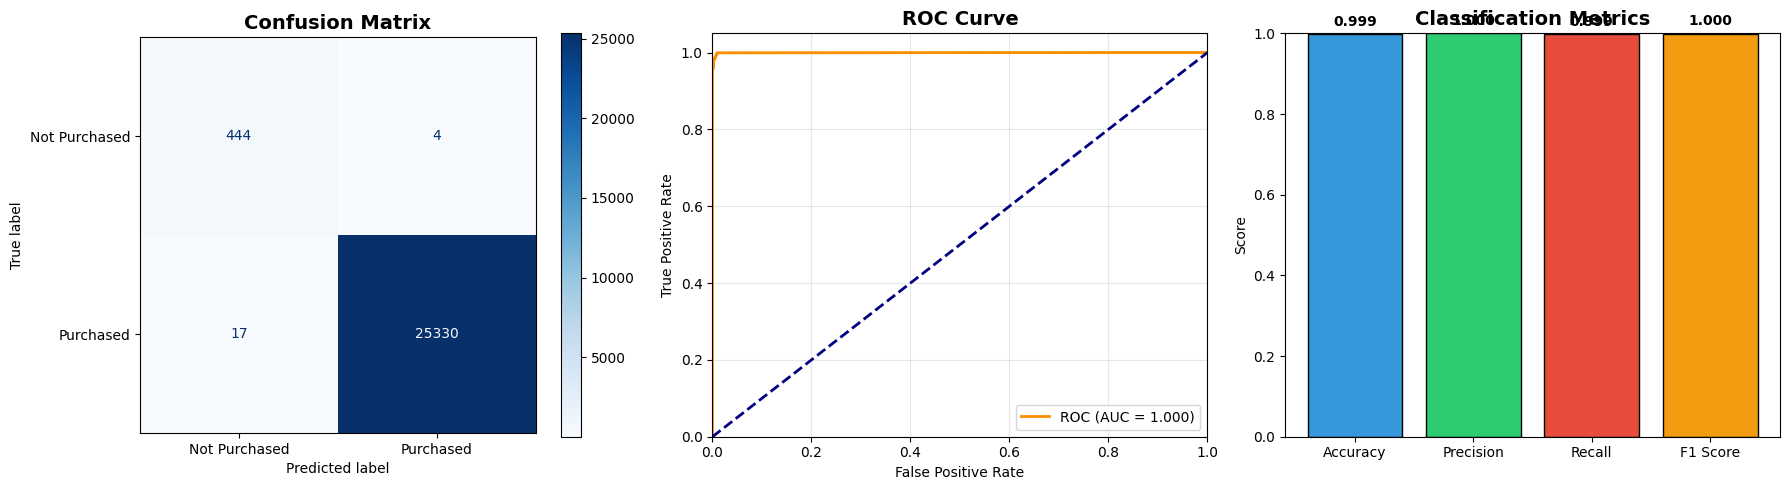

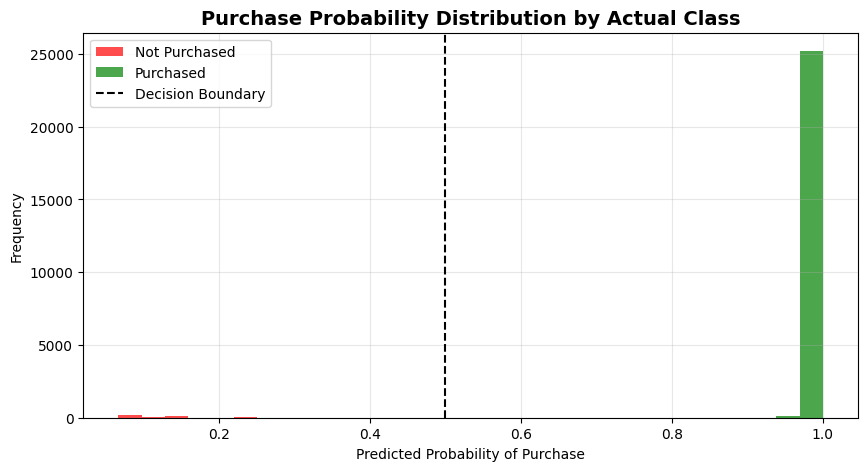

In [61]:
# Logistic Regression - Purchase Prediction
print(" Logistic Regression - Purchase Prediction")

logreg = LogisticRegression(max_iter=1000, random_state=42)
param_grid_log = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
print(" Hyperparameter grid for tuning:")
print(f" C: {param_grid_log['C']}")
print(f" solver: {param_grid_log['solver']}")


grid_log = GridSearchCV(logreg, param_grid_log, cv=5, scoring='accuracy')
grid_log.fit(X_train_clf, y_clf_train)

best_log = grid_log.best_estimator_
print(f"\n Best parameters: {grid_log.best_params_}")

y_pred_clf = best_log.predict(X_test_clf)
y_pred_proba = best_log.predict_proba(X_test_clf)

accuracy = accuracy_score(y_clf_test, y_pred_clf)
precision = precision_score(y_clf_test, y_pred_clf)
recall = recall_score(y_clf_test, y_pred_clf)
f1 = f1_score(y_clf_test, y_pred_clf)
cm = confusion_matrix(y_clf_test, y_pred_clf)

print(f"\n Classification Performance Metrics:")
print(f"   Accuracy:  {accuracy:.3f}")
print(f"   Precision: {precision:.3f}")
print(f"   Recall:    {recall:.3f}")
print(f"   F1 Score:  {f1:.3f}")

print(f"\n Confusion Matrix:")
print("                 Predicted")
print("                 No    Yes")
print(f"   Actual No    {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"   Actual Yes   {cm[1,0]:4d}  {cm[1,1]:4d}")

# Show sample predictions with probabilities


from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_proba[:, 1])
auc_score = roc_auc_score(y_clf_test, y_pred_proba[:, 1])

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

# Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[2].bar(metrics, values, color=colors, edgecolor='black')
axes[2].set_ylim([0, 1])
axes[2].set_ylabel('Score')
axes[2].set_title('Classification Metrics', fontsize=14, fontweight='bold')
for i, v in enumerate(values):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Probability Distribution graphs
plt.figure(figsize=(10, 5))
plt.hist(y_pred_proba[y_clf_test == 0][:, 1], bins=30, alpha=0.7, label='Not Purchased', color='red')
plt.hist(y_pred_proba[y_clf_test == 1][:, 1], bins=30, alpha=0.7, label='Purchased', color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Boundary')
plt.xlabel('Predicted Probability of Purchase')
plt.ylabel('Frequency')
plt.title('Purchase Probability Distribution by Actual Class', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 K-Means Clustering Customer Segmentation
 Created user features: 128975 users
 Scaling complete

 Finding optimal K using Elbow Method (fast)...
   Using 500 samples for silhouette calculation (faster)
   Testing K=2... Inertia: 625106, Silhouette: 0.351
   Testing K=3... Inertia: 397272, Silhouette: 0.400
   Testing K=4... Inertia: 298494, Silhouette: 0.348
   Testing K=5... Inertia: 228208, Silhouette: 0.367
   Testing K=6... Inertia: 180104, Silhouette: 0.382
   Testing K=7... Inertia: 150155, Silhouette: 0.384


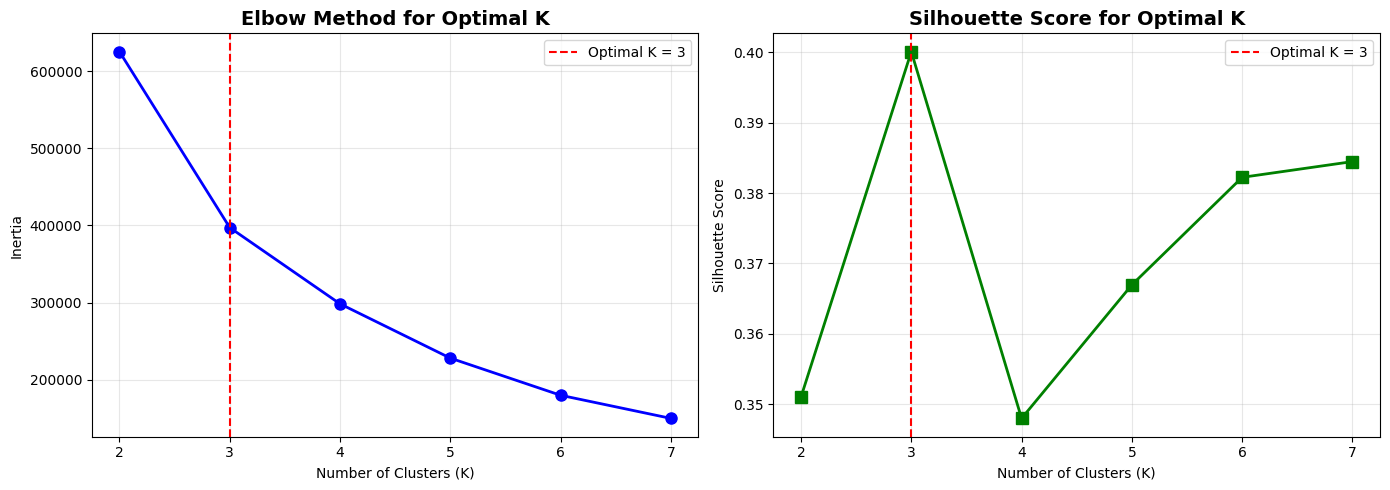


 Optimal K = 3 (based on highest silhouette score)

 Training final K-Means with K=3 on full dataset...

 Final Clustering Performance:
   Silhouette Score (full): 0.384
   Inertia:                397271.85
   Cluster sizes:          [37241, 2278, 89456]


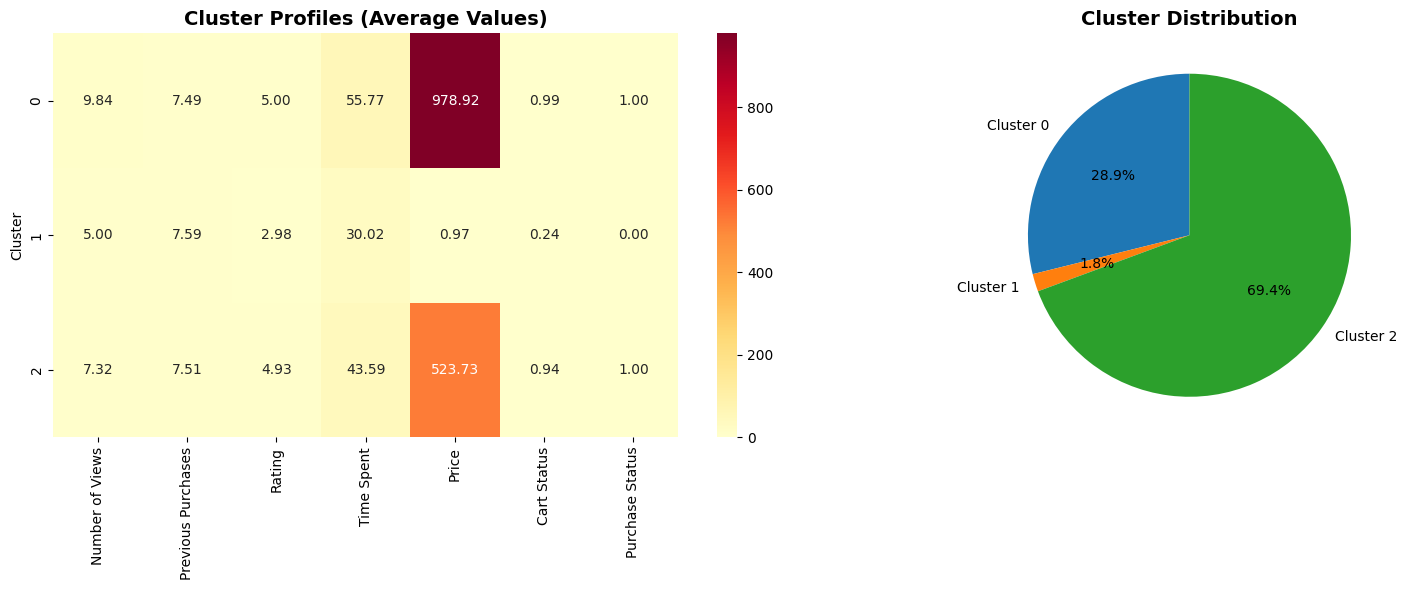

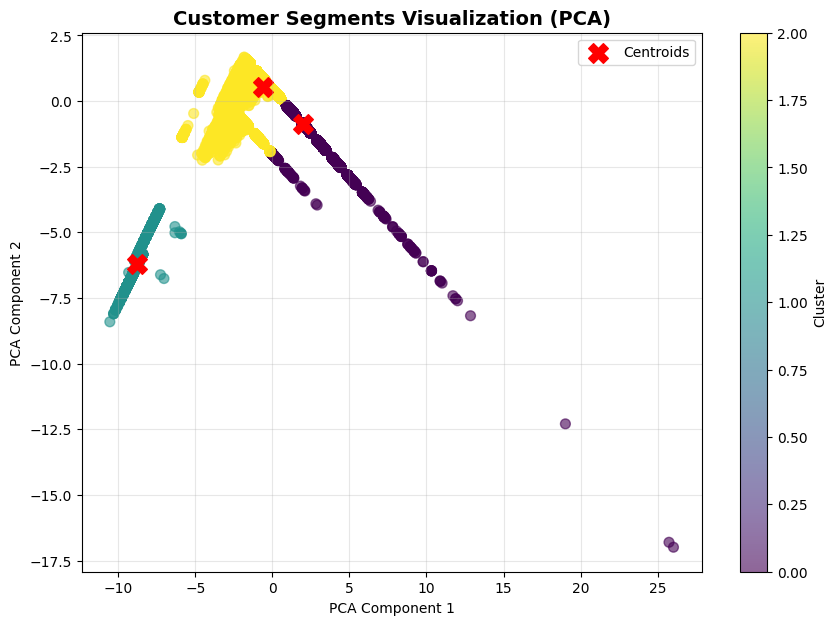


 Cluster Profiles (Average values per group):
         Number of Views  Previous Purchases  Rating  Time Spent   Price  \
Cluster                                                                    
0                   9.84                7.49    5.00       55.77  978.92   
1                   5.00                7.59    2.98       30.02    0.97   
2                   7.32                7.51    4.93       43.59  523.73   

         Cart Status  Purchase Status  
Cluster                                
0               0.99              1.0  
1               0.24              0.0  
2               0.94              1.0  

 Cluster Interpretation:
   Cluster 0:  High-value customers (High spending)
   Cluster 1:  Occasional buyers (Low activity)
   Cluster 2:  Loyal buyers (High purchase rate)

✅ Clustering complete! (Fast execution)


In [62]:
#K-Means Clustering - Customer Segmentation (FAST & RELIABLE)

try:
    df
except NameError:
    raise


print(" K-Means Clustering Customer Segmentation")


# Aggregate user features
df['User ID'] = df['User ID'].astype(str)

user_features = df.groupby('User ID').agg({
    'Number of Views': 'mean',
    'Previous Purchases': 'mean',
    'Rating': 'mean',
    'Time Spent': 'mean',
    'Price': 'mean',
    'Cart Status': 'mean',
    'Purchase Status': 'mean'
}).reset_index()

print(f" Created user features: {user_features.shape[0]} users")

# Scale features
feature_cols = ['Number of Views', 'Previous Purchases', 'Rating', 'Time Spent', 'Price', 'Cart Status', 'Purchase Status']
scaler_user = StandardScaler()
user_scaled = scaler_user.fit_transform(user_features[feature_cols])
print(f" Scaling complete")

# Use only inertia (Elbow) for speed, and sample for silhouette
print(f"\n Finding optimal K using Elbow Method (fast)...")
inertias = []
k_range = range(2, 8)

# For silhouette, use a sample if dataset is large
sample_size = min(500, len(user_scaled))
if len(user_scaled) > 500:
    sample_indices = np.random.choice(len(user_scaled), sample_size, replace=False)
    user_scaled_sample = user_scaled[sample_indices]
    print(f"   Using {sample_size} samples for silhouette calculation (faster)")
else:
    user_scaled_sample = user_scaled
    print(f"   Using all {len(user_scaled)} samples")

silhouette_scores = []

for k in k_range:
    print(f"   Testing K={k}...", end=" ")
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km.fit(user_scaled)
    inertias.append(km.inertia_)

    # Silhouette on sample (fast)
    km_sample = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km_sample.fit(user_scaled_sample)
    sil_score = silhouette_score(user_scaled_sample, km_sample.labels_)
    silhouette_scores.append(sil_score)
    print(f"Inertia: {km.inertia_:.0f}, Silhouette: {sil_score:.3f}")

# Elbow Method and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Scores
axes[1].plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Choose optimal K highest silhouette, or elbow
optimal_k = k_range[np.argmax(silhouette_scores)]
axes[0].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
axes[0].legend()
axes[1].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n Optimal K = {optimal_k} (based on highest silhouette score)")

#  K-Means on full data
print(f"\n Training final K-Means with K={optimal_k} on full dataset...")
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=200)
clusters = final_kmeans.fit_predict(user_scaled)

user_features['Cluster'] = clusters
# Compute final silhouette on full data (only once)
final_silhouette = silhouette_score(user_scaled, clusters)
final_inertia = final_kmeans.inertia_

print(f"\n Final Clustering Performance:")
print(f"   Silhouette Score (full): {final_silhouette:.3f}")
print(f"   Inertia:                {final_inertia:.2f}")
print(f"   Cluster sizes:          {pd.Series(clusters).value_counts().sort_index().tolist()}")

# Cluster Profiles
cluster_profiles = user_features[feature_cols + ['Cluster']].groupby('Cluster').mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster Profiles Heatmap
sns.heatmap(cluster_profiles, annot=True, cmap='YlOrRd', fmt='.2f', ax=axes[0])
axes[0].set_title('Cluster Profiles (Average Values)', fontsize=14, fontweight='bold')

# Cluster Distribution Pie Chart
cluster_sizes = user_features['Cluster'].value_counts().sort_index()
axes[1].pie(cluster_sizes.values, labels=[f'Cluster {i}' for i in cluster_sizes.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Cluster Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 2D Cluster Visualization using PCA
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
user_pca = pca.fit_transform(user_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(user_pca[:, 0], user_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments Visualization (PCA)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add cluster centers
centers_pca = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.legend()
plt.show()

print(f"\n Cluster Profiles (Average values per group):")
print(cluster_profiles)

# Business Interpretation
print("\n Cluster Interpretation:")
for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    avg_price = cluster_profiles['Price'].mean()
    avg_views = cluster_profiles['Number of Views'].mean()
    avg_cart = cluster_profiles['Cart Status'].mean()
    avg_purchase = cluster_profiles['Purchase Status'].mean()

    if profile['Price'] > avg_price * 1.3:
        print(f"   Cluster {cluster}:  High-value customers (High spending)")
    elif profile['Number of Views'] > avg_views * 1.4 and profile['Purchase Status'] < 0.4:
        print(f"   Cluster {cluster}: Window shoppers (Many views, few purchases)")
    elif profile['Cart Status'] > avg_cart * 1.3:
        print(f"   Cluster {cluster}: Cart abandoners (Add to cart but don't buy)")
    elif profile['Purchase Status'] > avg_purchase * 1.3:
        print(f"   Cluster {cluster}:  Loyal buyers (High purchase rate)")
    else:
        print(f"   Cluster {cluster}:  Occasional buyers (Low activity)")

print(f"\n✅ Clustering complete! (Fast execution)")

Integrated Recommendation Engine
 Loaded 128975 users with clusters
 Training columns: 13 features
No product name column found.
 Found 128975 common users

 Generating recommendations for sample user

User: U07012 (Cluster: 1)
Product Name Category  Predicted Rating  Buy Probability  Score
  Set B0894Y      Set               5.0            0.997  0.999
Kurta B09K3T    Kurta               5.0            0.966  0.986
  Set B07JP6      Set               5.0            0.960  0.984
  Set B09G2T      Set               5.0            0.949  0.980
Kurta B09SDX    Kurta               5.0            0.903  0.961
User: U117703 (Cluster: 2)
        Product Name      Category  Predicted Rating  Buy Probability  Score
Western Dress B09TY2 Western Dress               5.0            0.999    1.0
          Set B08WHX           Set               5.0            1.000    1.0
          Set B08WHT           Set               5.0            1.000    1.0
          Set B08YN7           Set               5.0 

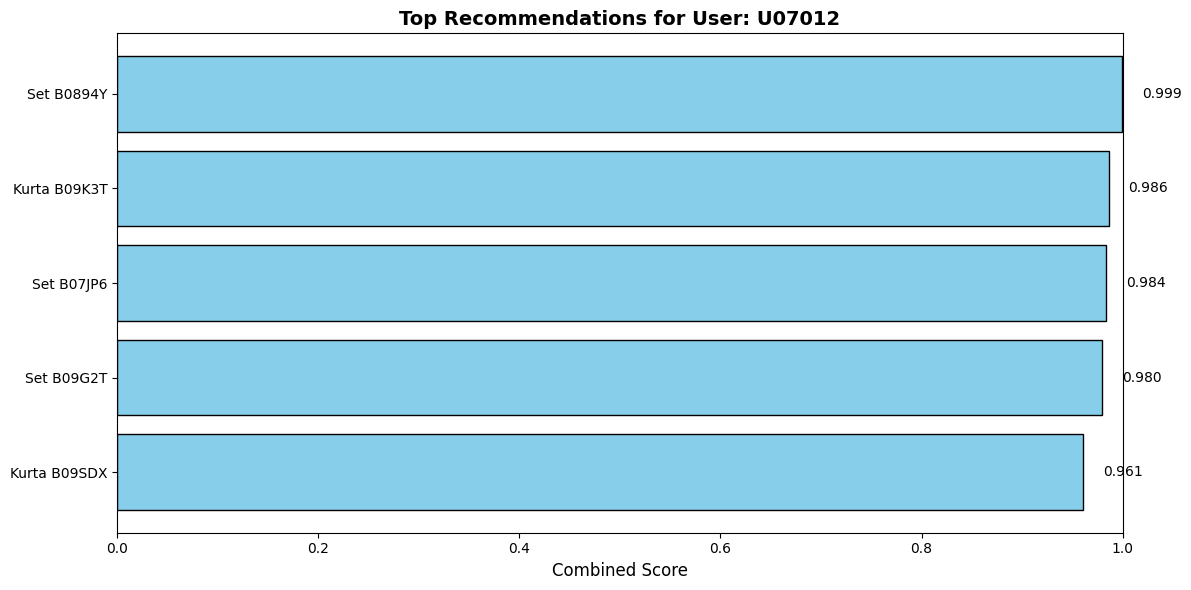

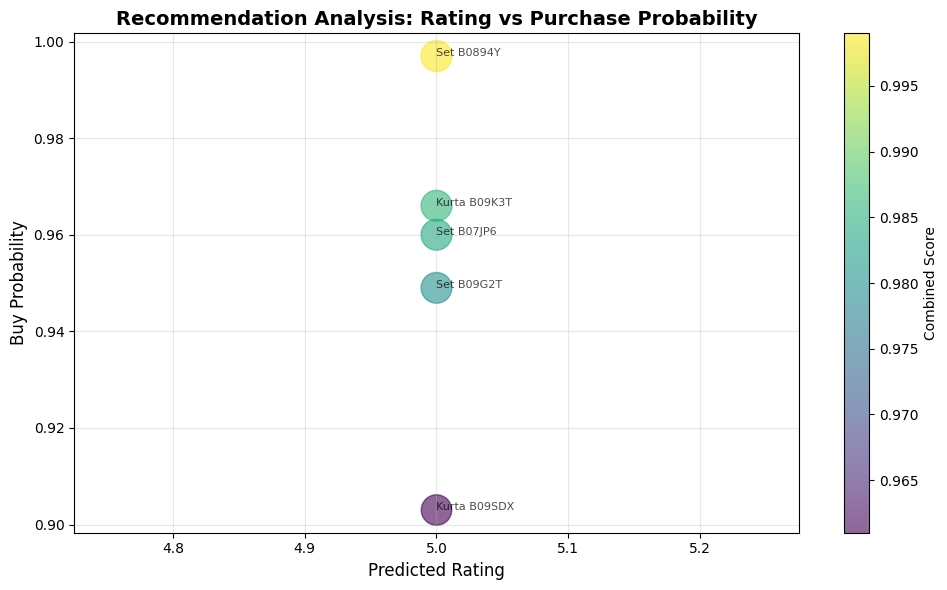

In [63]:
# CELL 8: Integrated Recommendation Engine with Proper Product Names

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Integrated Recommendation Engine")


# Safety Check
required_vars = ['best_ridge', 'best_log', 'scaler', 'X_scaled', 'df_encoded', 'num_cols', 'df']
missing = [v for v in required_vars if v not in dir()]
if missing:
    print(f" ERROR: Missing variables: {missing}")
    raise NameError(f"Missing variables: {missing}")

# Create user cluster mapping
user_cluster_map = user_features.set_index('User ID')['Cluster'].to_dict()
print(f" Loaded {len(user_cluster_map)} users with clusters")

# Get feature columns used during training
training_columns = X_scaled.columns.tolist()
print(f" Training columns: {len(training_columns)} features")

# SMART PRODUCT NAME DETECTION
product_name_col = None
name_candidates = ['product_name', 'product_title', 'title', 'name', 'description', 'item_name']
for col in df.columns:
    col_lower = col.lower()
    for candidate in name_candidates:
        if candidate in col_lower:
            product_name_col = col
            break
    if product_name_col:
        break

if product_name_col:
    print(f" Found product name column: '{product_name_col}'")
else:
    print("No product name column found.")

def get_product_name(product_id):

    try:
        if product_name_col:
            name = df[df['Product ID'] == product_id][product_name_col].iloc[0]
            # If name is too long, truncate
            if isinstance(name, str):
                return name[:30] if len(name) > 30 else name
            else:
                return str(name)[:30]
        else:
            # Create readable name: Category + short ID
            category = df[df['Product ID'] == product_id]['Product Category'].iloc[0]
            short_id = str(product_id)[:6]
            return f"{category} {short_id}"
    except:
        return str(product_id)[:15]

def get_recommendations(user_id, top_n=5):

    user_id = str(user_id)

    if user_id not in user_cluster_map:
        return f"  User {user_id} not found"

    # Get user's purchased products
    purchased = df[df['User ID'].astype(str) == user_id]['Product ID'].unique()
    all_products = df['Product ID'].unique()
    candidates = [p for p in all_products if p not in purchased]

    if not candidates:
        return " User has purchased all products!"

    # Take random candidates
    candidates = np.random.choice(candidates, min(10, len(candidates)), replace=False)
    user_row = df[df['User ID'].astype(str) == user_id].iloc[0]
    results = []

    for prod in candidates:
        # Get product's category and name
        prod_category = df[df['Product ID'] == prod]['Product Category'].iloc[0]
        prod_name = get_product_name(prod)

        # Create an empty DataFrame with all training columns, filled with zeros
        input_df = pd.DataFrame(0, index=[0], columns=training_columns)

        # Fill numerical features
        input_df['Price'] = df[df['Product ID'] == prod]['Price'].iloc[0]
        input_df['Number of Views'] = user_row['Number of Views'] * np.random.uniform(0.8, 1.2)
        input_df['Time Spent'] = user_row['Time Spent'] * np.random.uniform(0.8, 1.2)
        input_df['Previous Purchases'] = user_row['Previous Purchases']

        # Cart Status (if it exists in training columns)
        if 'Cart Status' in training_columns:
            input_df['Cart Status'] = user_row['Cart Status']

        # Populate the correct one-hot encoded category column
        category_col_name = f'Product Category_{prod_category}'
        if category_col_name in training_columns:
            input_df[category_col_name] = 1

        # Scale numerical features
        scaled_features_for_transform = input_df[num_cols]
        input_scaled_values = scaler.transform(scaled_features_for_transform)
        scaled_part_df = pd.DataFrame(input_scaled_values, columns=num_cols, index=input_df.index)

        # Get unscaled other columns
        unscaled_other_cols = [col for col in training_columns if col not in num_cols]
        final_input_for_prediction = pd.concat([scaled_part_df, input_df[unscaled_other_cols]], axis=1)
        final_input_for_prediction = final_input_for_prediction[training_columns]

        # Predict
        pred_rating = best_ridge.predict(final_input_for_prediction)[0]
        pred_prob = best_log.predict_proba(final_input_for_prediction)[0][1]

        # Cap predicted rating at 5
        pred_rating = min(pred_rating, 5.0)

        # Combined score (normalized to 0-1 range)
        combined = 0.6 * (pred_rating / 5) + 0.4 * pred_prob

        results.append({
            'Product ID': str(prod)[:15],
            'Product Name': prod_name,
            'Category': prod_category[:15],
            'Predicted Rating': round(pred_rating, 2),
            'Buy Probability': round(pred_prob, 3),
            'Score': round(combined, 3)
        })

    return pd.DataFrame(results).sort_values('Score', ascending=False).head(top_n)

# Find common users
df['User ID'] = df['User ID'].astype(str)
common_users = list(set(df['User ID'].unique()).intersection(set(user_cluster_map.keys())))

print(f" Found {len(common_users)} common users")

if len(common_users) > 0:
    sample_users = common_users[:2]
    print(f"\n Generating recommendations for sample user\n")

    all_recommendations = []
    for user in sample_users:
        print(f"User: {user} (Cluster: {user_cluster_map[user]})")
        recs = get_recommendations(user)
        if isinstance(recs, pd.DataFrame):
            # Display with product names
            display_df = recs[['Product Name', 'Category', 'Predicted Rating', 'Buy Probability', 'Score']]
            print(display_df.to_string(index=False))
            recs['User'] = user
            all_recommendations.append(recs)
        else:
            print(recs)

    # Recommendation Scores Bar Chart with Product Names
    if all_recommendations:
        first_user_recs = all_recommendations[0]
        if isinstance(first_user_recs, pd.DataFrame) and len(first_user_recs) > 0:
            plt.figure(figsize=(12, 6))
            # Use Product Name for y-axis labels
            product_labels = first_user_recs['Product Name'].tolist()
            scores = first_user_recs['Score'].tolist()

            bars = plt.barh(product_labels, scores, color='skyblue', edgecolor='black')
            plt.xlabel('Combined Score', fontsize=12)
            plt.title(f'Top Recommendations for User: {first_user_recs.iloc[0]["User"]}', fontsize=14, fontweight='bold')
            plt.xlim(0, 1)
            plt.gca().invert_yaxis()
            for bar, score in zip(bars, scores):
                plt.text(score + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.3f}', va='center', fontsize=10)
            plt.tight_layout()
            plt.show()

            # Ratings vs Probability Scatter
            fig, ax = plt.subplots(figsize=(10, 6))
            scatter = ax.scatter(first_user_recs['Predicted Rating'],
                               first_user_recs['Buy Probability'],
                               s=first_user_recs['Score']*500,
                               alpha=0.6,
                               c=first_user_recs['Score'],
                               cmap='viridis')
            plt.colorbar(scatter, label='Combined Score')

            # Add product labels
            for i, row in first_user_recs.iterrows():
                ax.annotate(row['Product Name'][:15],
                           (row['Predicted Rating'], row['Buy Probability']),
                           fontsize=8, alpha=0.7)

            ax.set_xlabel('Predicted Rating', fontsize=12)
            ax.set_ylabel('Buy Probability', fontsize=12)
            ax.set_title('Recommendation Analysis: Rating vs Purchase Probability', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


FINAL MODEL COMPARISON


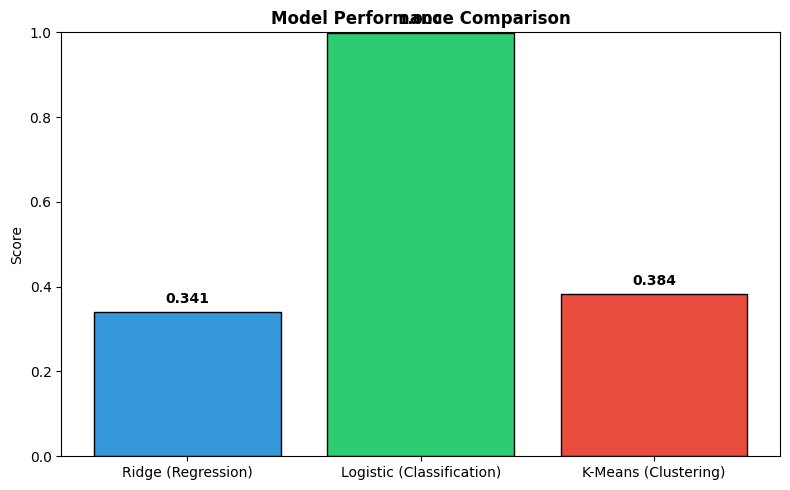


 PERFORMANCE TABLE
Task            Algorithm            Best Metric     Business Use
Regression      Ridge Regression     R² = 0.341      Personalization / Ranking
Classification  Logistic Regression  F1 = 1.000      Conversion / Targeting
Clustering      K-Means              Silhouette = 0.384 Segmentation / Marketing

1. REGRESSION (R² = 0.341)
  Low.

2.  CLASSIFICATION (F1 = 1.000)
   Good. 

3. CLUSTERING (Silhouette = 0.384)
  Moderate separation. 

 Customer Segments Found: 3
   Cluster 0: Avg Price ₹979, Views 10, Rating 5.00
   Cluster 1: Avg Price ₹1, Views 5, Rating 2.98
   Cluster 2: Avg Price ₹524, Views 7, Rating 4.93


In [64]:
#Final Model Comparison & Business Conclusion

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


print("FINAL MODEL COMPARISON")


# Safety Check
required = ['r2', 'f1', 'final_silhouette', 'optimal_k', 'cluster_profiles']
missing = [v for v in required if v not in locals() and v not in globals()]
if missing:
    print(f" Missing: {missing}. Run Cells 1-7 first.")
    raise SystemExit

# Performance Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Ridge (Regression)', 'Logistic (Classification)', 'K-Means (Clustering)']
metrics = [r2, f1, final_silhouette]
bars = ax.bar(models, metrics, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
for bar, val in zip(bars, metrics):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

#  Comparison Table
print("\n PERFORMANCE TABLE")

print(f"{'Task':<15} {'Algorithm':<20} {'Best Metric':<15} {'Business Use'}")
print(f"{'Regression':<15} {'Ridge Regression':<20} {f'R² = {r2:.3f}':<15} {'Personalization / Ranking'}")
print(f"{'Classification':<15} {'Logistic Regression':<20} {f'F1 = {f1:.3f}':<15} {'Conversion / Targeting'}")
print(f"{'Clustering':<15} {'K-Means':<20} {f'Silhouette = {final_silhouette:.3f}':<15} {'Segmentation / Marketing'}")


# Regression
print(f"\n1. REGRESSION (R² = {r2:.3f})")
if r2 >= 0.6:
    print("   Reliable.")
elif r2 >= 0.4:
    print("  Moderate. ")
else:
    print("  Low.")

# Classification
print(f"\n2.  CLASSIFICATION (F1 = {f1:.3f})")
if f1 >= 0.7:
    print("   Good. ")
elif f1 >= 0.5:
    print("   Moderate.")
else:
    print(" Low.")

# Clustering
print(f"\n3. CLUSTERING (Silhouette = {final_silhouette:.3f})")
if final_silhouette >= 0.4:
    print("  Well-separated segments.")
elif final_silhouette >= 0.2:
    print("  Moderate separation. ")
else:
    print("  Poor separation.")

# Segment details
print(f"\n Customer Segments Found: {optimal_k}")
if 'cluster_profiles' in locals():
    for c in range(optimal_k):
        p = cluster_profiles.loc[c]
        print(f"   Cluster {c}: Avg Price ₹{p['Price']:.0f}, Views {p['Number of Views']:.0f}, Rating {p['Rating']:.2f}")

